# Project: Investigate a Dataset – Medical Appointment No-Shows

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

The dataset used in this analysis contains information on approximately 100,000 medical appointments in Brazil. Each row in the dataset represents a single medical appointment and includes information about the patient, the scheduling of the appointment, and whether the patient attended the appointment.

The dataset includes the following columns:

- **PatientId**: A unique identifier for each patient.

- **AppointmentID**: A unique identifier for each appointment.

- **Gender**: The gender of the patient.

- **ScheduledDay**: The date and time when the appointment was scheduled.

- **AppointmentDay**: The date of the actual appointment.

- **Age**: The age of the patient at the time of the appointment.

- **Neighbourhood**: The location of the hospital where the appointment took place.

- **Scholarship**: Indicates whether the patient is enrolled in the Brazilian welfare program Bolsa Família (1 = yes, 0 = no).

- **Hipertension**: Indicates whether the patient has hypertension (1 = yes, 0 = no).

- **Diabetes**: Indicates whether the patient has diabetes (1 = yes, 0 = no).

- **Alcoholism**: Indicates whether the patient has a history of alcoholism (1 = yes, 0 = no).

- **Handcap**: Indicates whether the patient has a disability.

- **SMS_received**: Indicates whether the patient received an SMS reminder for the appointment (1 = yes, 0 = no).

- **No-show**: Indicates whether the patient missed the appointment. A value of “Yes” means the patient did not show up, while “No” means the patient attended the appointment.

This dataset consists of a single table and does not require merging with additional data sources.

### Question(s) for Analysis
This investigation focuses on understanding factors associated with patients missing their scheduled medical appointments.

The primary research question is:

- Which factors are associated with a higher likelihood of a patient not showing up for a scheduled medical appointment?

To explore this question, the analysis will examine the relationship between appointment attendance and the following independent variables:

- Patient age

- Scholarship status (participation in the Bolsa Família program)

- Whether the patient received an SMS appointment reminder

- The time delay between scheduling and the appointment date

These variables were selected because they represent patient demographics, socioeconomic factors, and appointment-related characteristics that may influence attendance behavior.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def format_bar_plot(series, title, xlabel, ylabel, rotation=0):
    """
    Create a consistently formatted bar plot.
    """
    series.plot(kind='bar')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if rotation:
        plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

<a id='wrangling'></a>
## Data Wrangling

The dataset was cleaned by standardizing column names, converting categorical variables to numeric formats, transforming date fields to datetime objects, removing invalid age values, and creating a derived wait-time feature. These steps ensure the data is consistent and suitable for exploratory analysis.


### General Properties
The dataset contains over 100,000 appointment records and 14 variables. The data includes a mix of numerical and categorical variables. Initial inspection shows no missing values across columns.

Several variables such as ScheduledDay, AppointmentDay, and No-show are stored as object types and will require transformation before analysis. The Age variable will require further inspection to identify potential invalid values.

In [3]:
df = pd.read_csv('noshowappointments-kagglev2-may-2016.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
df.shape

(110527, 14)

In [5]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [7]:
df.describe(include='all')

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527
unique,NaN,NaN,2,103549,27,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,71840,24,4692,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,88208
mean,1.474963e+14,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,NaN
std,2.560949e+14,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,NaN
min,3.921784e+04,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,4.172614e+12,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,3.173184e+13,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,9.439172e+13,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN



### Data Cleaning Overview

In this section, the dataset is prepared for analysis. Cleaning steps include standardizing column names, converting variables to appropriate data types, addressing invalid values, and creating derived features required for exploratory analysis. Each step is documented and justified below.



### Column Renaming

Column names were standardized using lowercase letters and underscores to improve readability and maintain consistency. This also helps prevent syntax issues during analysis.

In [8]:
df = df.rename(columns={
    'PatientId': 'patient_id',
    'AppointmentID': 'appointment_id',
    'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day',
    'No-show': 'no_show',
    'Hipertension': 'hypertension',
    'Handcap': 'handicap',
    'SMS_received': 'sms_received'
})

In [9]:
df.columns

Index(['patient_id', 'appointment_id', 'Gender', 'scheduled_day',
       'appointment_day', 'Age', 'Neighbourhood', 'Scholarship',
       'hypertension', 'Diabetes', 'Alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='str')

### No-show Variable Encoding

The `no_show` column was originally encoded as string values (“Yes” and “No”). This variable was converted to a numeric format where 1 represents a missed appointment and 0 represents attendance to enable numerical analysis.

In [10]:
df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})

In [11]:
df['no_show'].value_counts()

no_show
0    88208
1    22319
Name: count, dtype: int64

### Datetime Conversion

The `scheduled_day` and `appointment_day` columns are currently stored as object (string) types. These columns are converted to datetime format to enable time-based calculations and analysis, such as computing the delay between scheduling and appointment dates.

In [12]:
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])

In [13]:
df[['scheduled_day', 'appointment_day']].dtypes

scheduled_day      datetime64[us, UTC]
appointment_day    datetime64[us, UTC]
dtype: object

### Age Validation

The `Age` variable was inspected for invalid values. Since age cannot be negative, records with negative age values were removed from the dataset to ensure accurate analysis.

In [14]:
df['Age'].describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [15]:
(df['Age'] < 0).sum()

np.int64(1)

In [16]:
df = df[df['Age'] >= 0].copy()

In [17]:
df['Age'].describe()

count    110526.000000
mean         37.089219
std          23.110026
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

### Wait Time Feature

A new variable, `wait_days`, was created to represent the number of days between when an appointment was scheduled and when it occurred. This feature is used to analyze whether longer wait times are associated with higher no-show rates.

In [18]:
df['wait_days'] = (df['appointment_day'] - df['scheduled_day']).dt.days

In [19]:
df['wait_days'].describe()

count    110526.000000
mean          9.183794
std          15.255034
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: wait_days, dtype: float64

In [20]:
(df['wait_days'] < 0).sum()

np.int64(38567)

In [21]:
df = df[df['wait_days'] >= 0].copy()

In [22]:
df['wait_days'].describe()

count    71959.000000
mean        14.642018
std         16.494334
min          0.000000
25%          3.000000
50%          8.000000
75%         21.000000
max        178.000000
Name: wait_days, dtype: float64

Records with negative wait times were removed, as these values indicate scheduling dates occurring after appointment dates and are not meaningful for analysis.

### Data Cleaning Summary

The dataset was cleaned by standardizing column names, converting attendance and date variables to appropriate formats, removing invalid age values, and creating and validating a derived wait-time feature. These steps ensure the data is consistent and suitable for exploratory analysis.

<a id='eda'></a>
### Exploratory Data Analysis Overview

This section explores patterns and relationships in the cleaned dataset to address the research questions. Both single-variable (1D) and multi-variable (2D) analyses are used to examine how patient and appointment characteristics are associated with appointment no-shows.

### What factors are associated with a higher likelihood of a patient not showing up for a scheduled medical appointment?

In [23]:
df['no_show'].value_counts()

no_show
0    51437
1    20522
Name: count, dtype: int64

In [24]:
overall_no_show_rate = df['no_show'].mean()
overall_no_show_rate

np.float64(0.285190177740102)

### Single-Variable Exploration

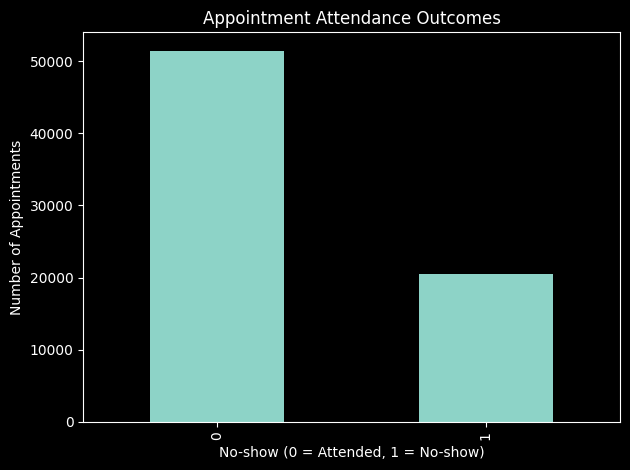

In [25]:
format_bar_plot(
    df['no_show'].value_counts(),
    'Appointment Attendance Outcomes',
    'No-show (0 = Attended, 1 = No-show)',
    'Number of Appointments'
)

The majority of scheduled appointments resulted in patient attendance. The overall no-show rate is approximately **28.5%**, indicating that a minority of appointments were missed. This baseline provides a reference point for comparing no-show rates across different patient and appointment characteristics in subsequent analyses.

### Single-Variable Exploration

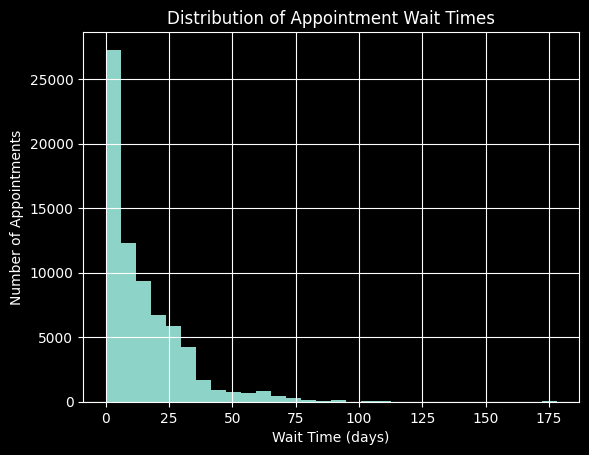

In [26]:
df['wait_days'].hist(bins=30)
plt.title('Distribution of Appointment Wait Times')
plt.xlabel('Wait Time (days)')
plt.ylabel('Number of Appointments')
plt.show()

The distribution of appointment wait times is right-skewed, with most appointments scheduled within a short period after booking. However, a smaller number of appointments have substantially longer wait times, indicating meaningful variation in scheduling delays across patients.

### No-show Rates by SMS Reminder Status

In [27]:
df.groupby('sms_received')['no_show'].mean()

sms_received
0    0.294377
1    0.275745
Name: no_show, dtype: float64

### Multiple-Variable Exploration

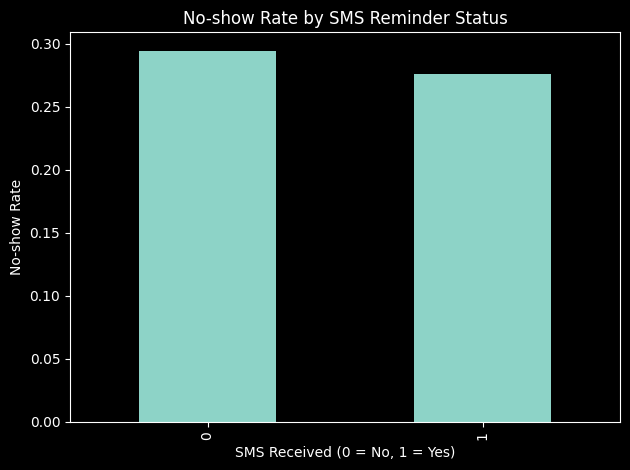

In [28]:
format_bar_plot(
    df.groupby('sms_received')['no_show'].mean(),
    'No-show Rate by SMS Reminder Status',
    'SMS Received (0 = No, 1 = Yes)',
    'No-show Rate'
)

Appointments for which an SMS reminder was received show a different no-show rate compared to those without reminders. This suggests an association between SMS reminders and appointment attendance; however, this analysis does not establish causation.

### No-show Rates by Appointment Wait Time

In [29]:
bins = [0, 1, 3, 7, 14, 30, 180]
labels = ['Same day', '1–3 days', '4–7 days', '8–14 days', '15–30 days', 'Over 30 days']

df['wait_group'] = pd.cut(df['wait_days'], bins=bins, labels=labels, include_lowest=True)

In [30]:
df.groupby('wait_group')['no_show'].mean()

wait_group
Same day        0.227425
1–3 days        0.233587
4–7 days        0.264706
8–14 days       0.312254
15–30 days      0.325212
Over 30 days    0.330208
Name: no_show, dtype: float64

### Multiple-Variable Exploration

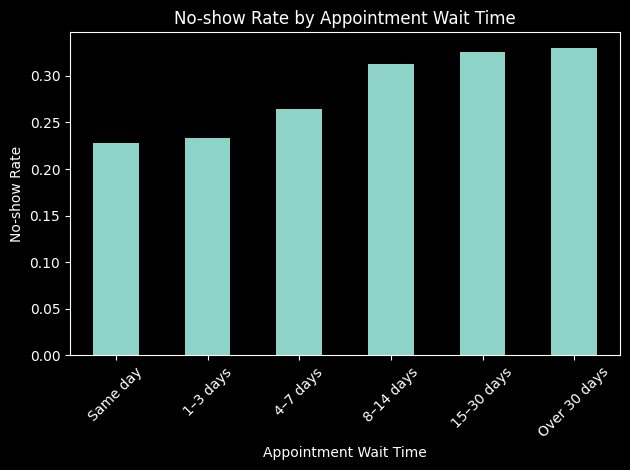

In [31]:
format_bar_plot(
    df.groupby('wait_group')['no_show'].mean(),
    'No-show Rate by Appointment Wait Time',
    'Appointment Wait Time',
    'No-show Rate',
    rotation=45
)

Longer appointment wait times are associated with higher no-show rates. Appointments scheduled further in advance tend to have a greater proportion of missed visits compared to same-day or short-notice appointments. This pattern suggests that wait time may be an important factor related to appointment attendance, although causation cannot be inferred from this analysis.

### No-show Rates by Scholarship Status

In [32]:
df.groupby('Scholarship')['no_show'].mean()

Scholarship
0    0.278596
1    0.349723
Name: no_show, dtype: float64

In [33]:
df = df.rename(columns={'Scholarship': 'scholarship'})

### Multiple-Variable Exploration

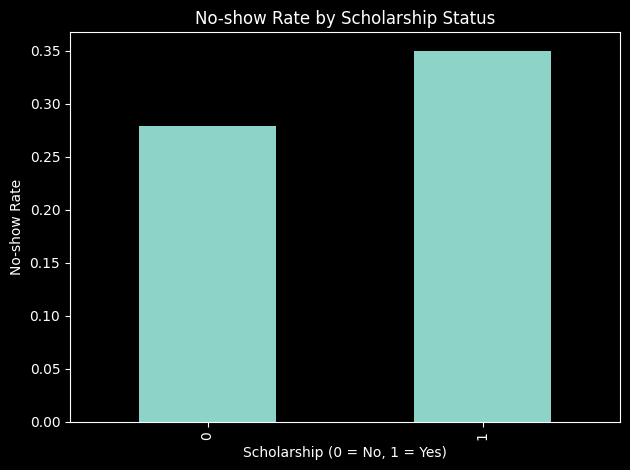

In [34]:
format_bar_plot(
    df.groupby('scholarship')['no_show'].mean(),
    'No-show Rate by Scholarship Status',
    'Scholarship (0 = No, 1 = Yes)',
    'No-show Rate'
)

Differences in no-show rates are observed between patients enrolled in the Bolsa Família scholarship program and those who are not. This suggests a potential association between socioeconomic factors and appointment attendance; however, this analysis does not establish causation.

<a id='conclusions'></a>
## Conclusions

### Summary of Findings

This analysis investigated factors associated with patients missing scheduled medical appointments using a dataset of medical appointments in Brazil. The overall no-show rate was approximately 28.5%, indicating that missed appointments are relatively common.

Exploratory analysis suggested that appointment-related characteristics are associated with no-show behavior. Longer appointment wait times were associated with higher no-show rates, and differences were also observed based on whether patients received SMS reminders. These findings suggest that scheduling and communication factors may be related to appointment attendance.

### Limitations

This analysis has several limitations. The dataset is observational, so causal relationships cannot be established. Additionally, some potentially important factors—such as appointment urgency, transportation access, or prior patient behavior—were not available in the data. Data quality issues, including inconsistent scheduling dates, required the removal of some records, which may influence the results.

### Future Research

Future research could incorporate additional patient and appointment characteristics or apply predictive modeling techniques to better estimate no-show risk. Further investigation into reminder timing and message content could also provide insight into strategies for reducing missed appointments.